#インポート

In [177]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker

#シード固定

In [178]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#デバイス・データセット・モデル定義

In [179]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = datasets.MNIST(root = "./data", train = True, transform = transforms.Compose([transforms.ToTensor()]), download = True)
test_dataset = datasets.MNIST(root = "./data", train = False, transform = transforms.Compose([transforms.ToTensor()]), download = True)

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 *28, 100)
        self.fc2 = nn.Linear(100, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

#学習率・エポック数・バッチサイズ指定、データローダー作る

In [180]:
set_seed(42)
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

LEARNING_RATE = 0.01
EPOCHS = 200

#学習ループ

##テストループ

In [181]:
#保留

##SGD

In [182]:
set_seed(42)
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

SGD_train_loss_history = []
SGD_test_loss_history = []
SGD_train_acc_history = []
SGD_test_acc_history = []
SGD_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0
    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    fg_count += 1
    train_loss /= len(train_loader)
    train_acc = correct / total

    SGD_x.append(fg_count)
    SGD_train_loss_history.append(train_loss)
    SGD_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    SGD_test_loss_history.append(test_loss)
    SGD_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 2500/2500 [00:04<00:00, 609.87it/s, loss=0.0124, acc=0.939]  


Train Loss: 0.3771, Acc: 0.8963 | Test Loss: 0.2147, Acc: 0.9390
epoch: 2


100%|██████████| 2500/2500 [00:04<00:00, 597.78it/s, loss=0.00613, acc=0.957] 


Train Loss: 0.1869, Acc: 0.9464 | Test Loss: 0.1494, Acc: 0.9565
epoch: 3


...

Train Loss: 0.0003, Acc: 1.0000 | Test Loss: 0.0922, Acc: 0.9808
epoch: 199


100%|██████████| 2500/2500 [00:03<00:00, 677.43it/s, loss=0, acc=0.981]       


Train Loss: 0.0003, Acc: 1.0000 | Test Loss: 0.0923, Acc: 0.9807
epoch: 200


100%|██████████| 2500/2500 [00:03<00:00, 680.48it/s, loss=0, acc=0.981]       

Train Loss: 0.0003, Acc: 1.0000 | Test Loss: 0.0921, Acc: 0.9806


##SVRG

In [183]:
set_seed(42)
class SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        # full_grad，prev_pを初期化
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['prev_p'] = torch.clone(p) # prev_pの初期値はパラメータ

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            # 平均の誤差にデータ数を掛け総和に変換
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue

                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)

    def culc_prev_grads(self, model, X, T, loss_func):
        # prev_pに切り替え
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"]) # パラメータをprev_vに変換

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_vに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                z = state['z']
                prev_grad = state["prev_grad"]
                # 補正勾配を更新
                v = grad - prev_grad + z

                # パラメータを更新
                p.sub_(v, alpha = lr)

        return loss

In [184]:
set_seed(42)
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = SVRG(model.parameters(), lr = LEARNING_RATE)

SVRG_train_loss_history = []
SVRG_test_loss_history = []
SVRG_train_acc_history = []
SVRG_test_acc_history = []
SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.calc_full_grads(model, train_loader, criterion)
    fg_count += 1

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    SVRG_x.append(fg_count)
    SVRG_train_loss_history.append(train_loss)
    SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    SVRG_test_loss_history.append(test_loss)
    SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 2500/2500 [00:03<00:00, 655.81it/s, loss=0.0179, acc=0.941]  


Train Loss: 0.3723, Acc: 0.9002 | Test Loss: 0.2085, Acc: 0.9414
epoch: 2


100%|██████████| 2500/2500 [00:03<00:00, 700.02it/s, loss=0.0056, acc=0.958]  


Train Loss: 0.1692, Acc: 0.9518 | Test Loss: 0.1436, Acc: 0.9581
epoch: 3


...

Train Loss: 0.0028, Acc: 1.0000 | Test Loss: 0.0775, Acc: 0.9802
epoch: 45


100%|██████████| 2500/2500 [00:03<00:00, 676.96it/s, loss=6.47e-6, acc=0.98]  


Train Loss: 0.0027, Acc: 1.0000 | Test Loss: 0.0779, Acc: 0.9803
epoch: 46


 76%|███████▌  | 11379/15000 [00:36<00:11, 309.26it/s, loss=5.25e-5, acc=1] 


KeyboardInterrupt: 

##No Full Grad SVRG

In [ ]:
set_seed(42)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p) # prev_aを'a'のクローンとして初期化

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_p'] = torch.clone(p).detach() # prev_pの初期値はパラメータ
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                # 補正勾配を更新
                v = grad - prev_grad + prev_a

                # パラメータを更新
                p.sub_(v, alpha = lr)
                state["t"] += 1

        return loss

In [ ]:
set_seed(42)
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

NFG_SVRG_train_loss_history = []
NFG_SVRG_test_loss_history = []
NFG_SVRG_train_acc_history = []
NFG_SVRG_test_acc_history = []
NFG_SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    NFG_SVRG_x.append(fg_count)
    NFG_SVRG_train_loss_history.append(train_loss)
    NFG_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    NFG_SVRG_test_loss_history.append(test_loss)
    NFG_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 40/40 [00:00<00:00, 113.58it/s, loss=2.32, acc=0.108]


Train Loss: 2.3092, Acc: 0.1082 | Test Loss: 2.3101, Acc: 0.1080
epoch: 2


100%|██████████| 40/40 [00:00<00:00, 127.46it/s, loss=1.64, acc=0.725]


Train Loss: 2.0466, Acc: 0.5232 | Test Loss: 1.7026, Acc: 0.7246
epoch: 3


...

Train Loss: 0.1744, Acc: 0.9514 | Test Loss: 0.1737, Acc: 0.9505
epoch: 99


100%|██████████| 40/40 [00:00<00:00, 112.58it/s, loss=0.0482, acc=0.951]


Train Loss: 0.1732, Acc: 0.9517 | Test Loss: 0.1728, Acc: 0.9507
epoch: 100


100%|██████████| 40/40 [00:00<00:00, 105.64it/s, loss=0.0474, acc=0.951]

Train Loss: 0.1720, Acc: 0.9519 | Test Loss: 0.1718, Acc: 0.9509


##Primal No Full Grad SVRG

In [ ]:
set_seed(42)
class Primal_NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["prev_z"] = torch.clone(p.detach())

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_z'].copy_(state["z"])
                state["z"].zero_()
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                z = state["z"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                # 補正勾配を更新
                v = grad - prev_grad + prev_a
                # パラメータを更新
                p.sub_(v, alpha = lr)
                # 平均パラメーターを更新
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))
                state["t"] += 1

        return loss

In [ ]:
set_seed(42)
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Primal_NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

Primal_NFG_SVRG_train_loss_history = []
Primal_NFG_SVRG_test_loss_history = []
Primal_NFG_SVRG_train_acc_history = []
Primal_NFG_SVRG_test_acc_history = []
Primal_NFG_SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    Primal_NFG_SVRG_x.append(fg_count)
    Primal_NFG_SVRG_train_loss_history.append(train_loss)
    Primal_NFG_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)

        backup = []
        with torch.no_grad():
            for group in optimizer.param_groups:
                for p in group['params']:
                    state = optimizer.state[p]
                    backup.append(p.clone())
                    p.copy_(state["z"])

        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        with torch.no_grad():
            i = 0
            for group in optimizer.param_groups:
                for p in group['params']:
                    p.copy_(backup[i])
                    i += 1

    test_loss /= len(test_loader)
    test_acc = correct / total

    Primal_NFG_SVRG_test_loss_history.append(test_loss)
    Primal_NFG_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


  0%|          | 0/235 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:00<00:00, 118.38it/s, loss=2.32, acc=0.108]


Train Loss: 2.3092, Acc: 0.1082 | Test Loss: 2.3101, Acc: 0.1080
epoch: 2


100%|██████████| 40/40 [00:00<00:00, 97.93it/s, loss=2.02, acc=0.643] 


...

Train Loss: 0.1718, Acc: 0.9520 | Test Loss: 0.1713, Acc: 0.9509
epoch: 99


100%|██████████| 40/40 [00:00<00:00, 108.56it/s, loss=0.0445, acc=0.951]


Train Loss: 0.1707, Acc: 0.9522 | Test Loss: 0.1703, Acc: 0.9510
epoch: 100


100%|██████████| 40/40 [00:00<00:00, 106.84it/s, loss=0.0437, acc=0.951]

Train Loss: 0.1695, Acc: 0.9526 | Test Loss: 0.1694, Acc: 0.9511


#結果

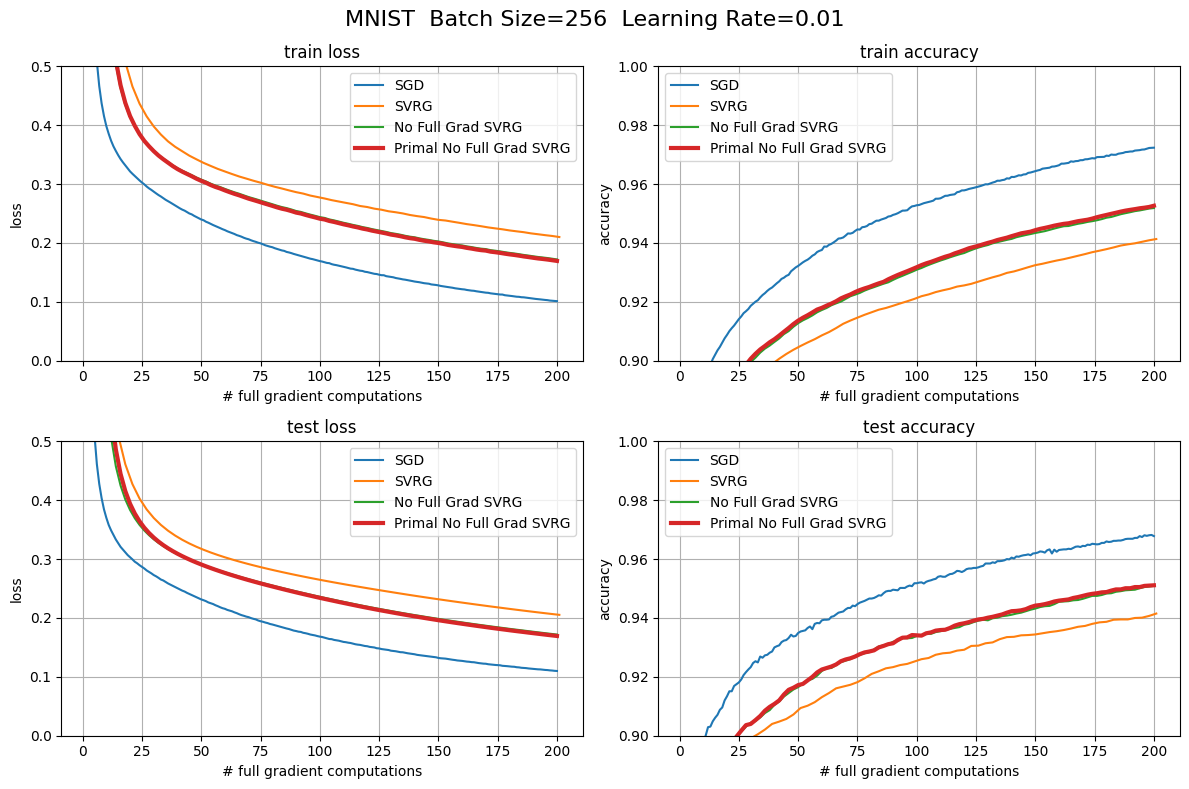

In [ ]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"MNIST  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(2, 2, 1)
ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_train_loss_history, label = "Primal No Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.set_ylim([0, 0.5])
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_train_acc_history, label = "Primal No Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.set_ylim([0.9, 1])
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_loss_history, label = "Primal No Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.set_ylim([0, 0.5])
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_acc_history, label = "Primal No Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.set_ylim([0.9, 1])
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

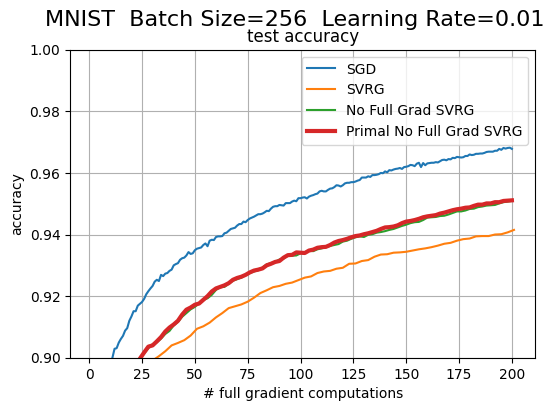

In [ ]:
fig = plt.figure(figsize = (6, 4))
fig.suptitle(f"MNIST  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)

ax = fig.add_subplot()
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_acc_history, label = "Primal No Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.set_ylim([0.9, 1])
ax.grid()
ax.legend()